In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/covid19-xray-dataset-train-test-sets/xray_dataset_covid19/test/PNEUMONIA/SARS-10.1148rg.242035193-g04mr34g04b-Fig4b-day12.jpeg
/kaggle/input/covid19-xray-dataset-train-test-sets/xray_dataset_covid19/test/PNEUMONIA/ryct.2020200034.fig5-day4.jpeg
/kaggle/input/covid19-xray-dataset-train-test-sets/xray_dataset_covid19/test/PNEUMONIA/SARS-10.1148rg.242035193-g04mr34g0-Fig8b-day5.jpeg
/kaggle/input/covid19-xray-dataset-train-test-sets/xray_dataset_covid19/test/PNEUMONIA/ryct.2020200034.fig5-day0.jpeg
/kaggle/input/covid19-xray-dataset-train-test-sets/xray_dataset_covid19/test/PNEUMONIA/SARS-10.1148rg.242035193-g04mr34g09a-Fig9a-day17.jpeg
/kaggle/input/covid19-xray-dataset-train-test-sets/xray_dataset_covid19/test/PNEUMONIA/ryct.2020200034.fig2.jpeg
/kaggle/input/covid19-xray-dataset-train-test-sets/xray_dataset_covid19/test/PNEUMONIA/streptococcus-pneumoniae-pneumonia-temporal-evolution-1-day3.jpg
/kaggle/input/covid19-xray-dataset-train-test-sets/xray_dataset_covid19/test/PN

## Libraries

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator


import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

## Import Data

In [3]:
image_train_dir='/kaggle/input/covid19-xray-dataset-train-test-sets/xray_dataset_covid19/train'
image_test_dir='/kaggle/input/covid19-xray-dataset-train-test-sets/xray_dataset_covid19/test'


## Data Generator

In [4]:
train_datagen=ImageDataGenerator(horizontal_flip=True,
                                rescale=1.0/255.0,
                                rotation_range=20,
                                width_shift_range=.2,
                                height_shift_range=.2,
                                shear_range=.2,
                                zoom_range=.2,
                                fill_mode='nearest',
                                validation_split=.2 )

test_datagen=ImageDataGenerator(rescale=1.0/255.0,validation_split=.2)

## Load Data

In [5]:
train_generator=train_datagen.flow_from_directory(image_train_dir,
                                                   target_size=(128,128),
                                                   batch_size=32,
                                                   shuffle=True,
                                                   color_mode='rgb',
                                                   subset='training',
                                                   class_mode='categorical')



validation_generator=train_datagen.flow_from_directory(image_train_dir,
                                                   target_size=(128,128),
                                                   batch_size=32,
                                                   shuffle=True,
                                                   color_mode='rgb',
                                                   subset='validation',
                                                   class_mode='categorical')


test_generator=test_datagen.flow_from_directory(image_train_dir,
                                                   target_size=(128,128),
                                                   batch_size=32,
                                                   shuffle=False,
                                                   color_mode='rgb',
                                                   class_mode='categorical')


Found 120 images belonging to 2 classes.
Found 28 images belonging to 2 classes.
Found 148 images belonging to 2 classes.


## plot Samples Of Data 

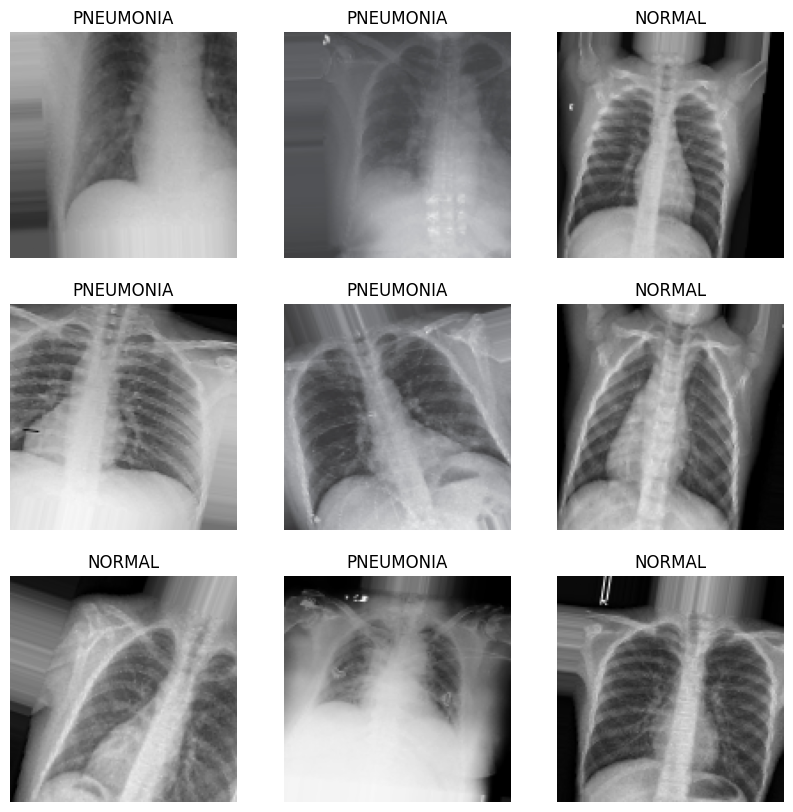

In [6]:
images,labels=next(train_generator)
class_names=list(train_generator.class_indices.keys())
plt.figure(figsize=(10,10))
for i  in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis('off')
plt.show()    
    
    




## Build Model

In [7]:
model=Sequential([Conv2D(32,(3,3),activation="relu",input_shape=(128,128,3)),
MaxPooling2D((2,2)),
Conv2D(64,(3,3),activation='relu'),
MaxPooling2D((2,2)),
Conv2D(128,(3,3),activation='relu'),
MaxPooling2D((2,2)),
Flatten(),
Dense(units=128,activation='relu'),
Dropout(.5),
Dense(2,activation='sigmoid')
])



/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Train The Model

In [8]:
model.compile(optimizer='adam',
loss='categorical_crossentropy',
metrics=['accuracy'])

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,304,898 (12.61 MB)

 Trainable params: 3,304,898 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
from tensorflow.keras.callbacks import EarlyStopping
earlystop=EarlyStopping()

In [11]:
history=model.fit(train_generator,
                 epochs=10,
                 callbacks=[earlystop],
                 validation_data=test_generator
                )


Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.4694 - loss: 0.7865 - val_accuracy: 0.5000 - val_loss: 0.6771
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.6194 - loss: 0.6576 - val_accuracy: 0.8784 - val_loss: 0.6504
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.6723 - loss: 0.6459 - val_accuracy: 0.8784 - val_loss: 0.5613
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.7933 - loss: 0.5803 - val_accuracy: 0.8311 - val_loss: 0.4270
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.7393 - loss: 0.5080 - val_accuracy: 0.8851 - val_loss: 0.3254
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.7850 - loss: 0.5135 - val_accuracy: 0.7432 - val_loss: 0.5525


## Plot 

Text(0.5, 1.0, 'Loss over Epochs')

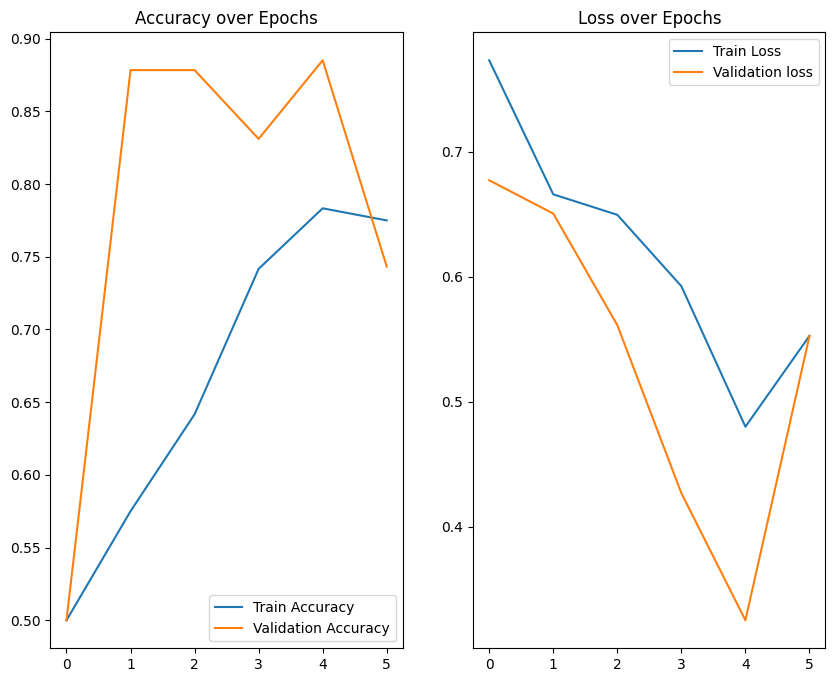

In [12]:
plt.figure(figsize=(10,8))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.legend()
plt.title('Accuracy over Epochs')


plt.subplot(1,2,2)
plt.plot(history.history['loss'],label='Train Loss')
plt.plot(history.history['val_loss'],label='Validation loss')
plt.legend()
plt.title('Loss over Epochs')